## Project2 Netflix / Media dataset EDA
- [Netflix Dataset](https://www.kaggle.com/datasets/shivamb/netflix-shows)
1. Counts by type (movie/TV), year trends and top genres.
2. Visualize content growth over time and runtime distributions.
3. Generate top-10 lists (most common genres, years).
4. Export visual report (plots + summary).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("netflix_titles.csv")
data.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Content type counts

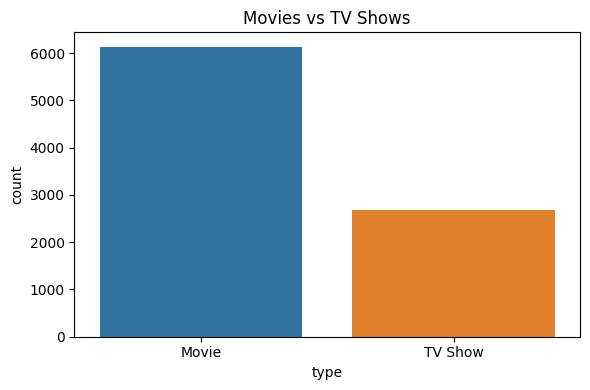

In [4]:
type_counts = data["type"].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(data=data , x="type")
plt.title("Movies vs TV Shows")
plt.tight_layout()
plt.savefig("content_type_counts.png")
plt.show()

In [5]:
print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


### Content growth by ```Year```

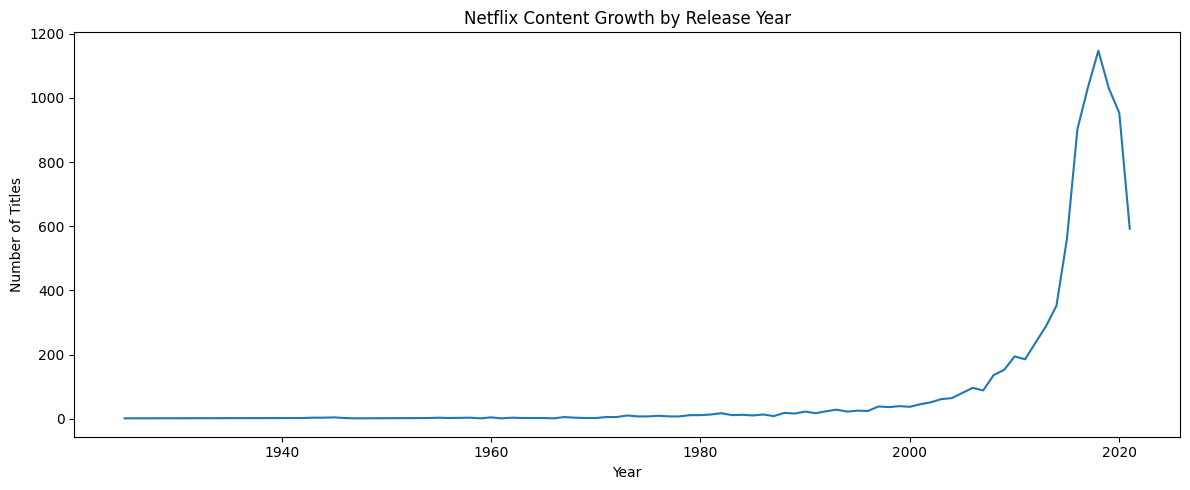

In [6]:
year_counts = data["release_year"].value_counts().sort_index()
plt.figure(figsize=(12,5))
year_counts.plot()
plt.title("Netflix Content Growth by Release Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("content_growth.png")
plt.show()

### Top genres

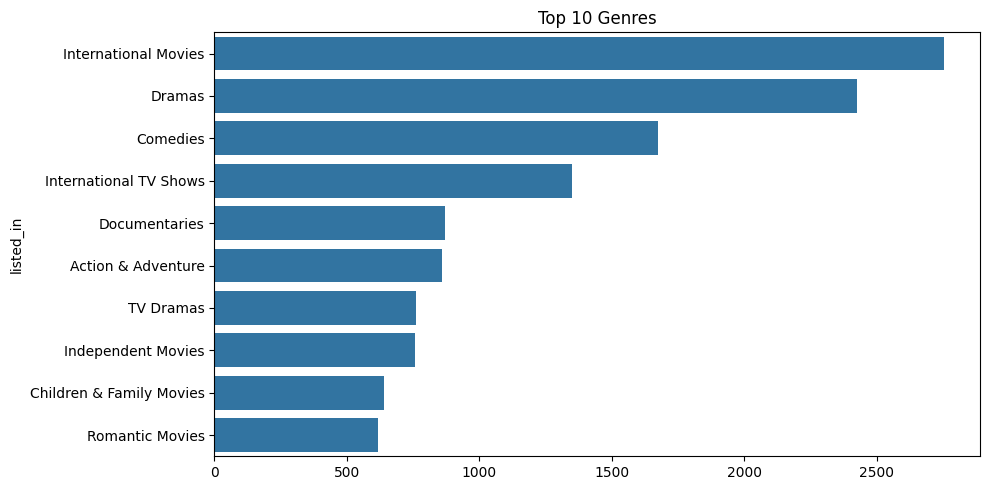

In [7]:
genres = (data["listed_in"].dropna().str.split(", ").explode())
top_genres = genres.value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values,y=top_genres.index,color='#1f77b4')
plt.title("Top 10 Genres")
plt.tight_layout()
plt.savefig("top_genres.png")
plt.show()

In [8]:
print("Top Genres:")
print(top_genres)

Top Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


### Runtime distribution

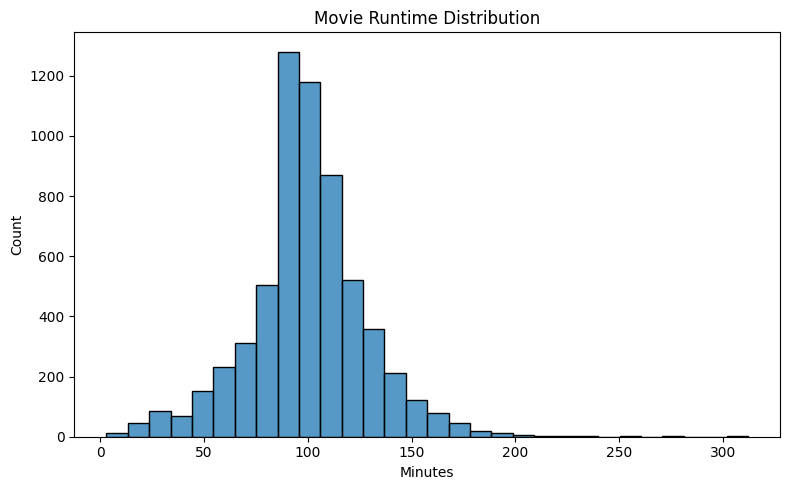

In [9]:
movies = data[data["type"]=="Movie"].copy()
movies["duration_num"] = (movies["duration"].str.extract(r'(\d+)').astype(float))
plt.figure(figsize=(8,5))
sns.histplot(movies["duration_num"],bins=30)
plt.title("Movie Runtime Distribution")
plt.xlabel("Minutes")
plt.tight_layout()
plt.savefig("runtime_distribution.png")
plt.show()

### Top 10 years

In [10]:
top_years = year_counts.sort_values(ascending=False).head(10)
print("Top 10 Years:")
print(top_years)

Top 10 Years:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


### Export summary

In [11]:
summary = pd.DataFrame({"Top Genres": top_genres.index,"Count": top_genres.values})
summary.to_csv("netflix_summary.csv",index=False)
print("Summary exported.")

Summary exported.


In [12]:
print("Insights")
print("1. Movie titles generally outnumber TV shows.")
print("2. The number of titles released each year has been increasing, especially in recent years.")
print("3. Drama and International Movies are the most popular genres.")
print("4. Most movies have a runtime between 80 and 120 minutes.")
print("5. The top years for content release are 2018, 2019, and 2020.")
print("6. There is a significant increase in content production in the last decade.")

Insights
1. Movie titles generally outnumber TV shows.
2. The number of titles released each year has been increasing, especially in recent years.
3. Drama and International Movies are the most popular genres.
4. Most movies have a runtime between 80 and 120 minutes.
5. The top years for content release are 2018, 2019, and 2020.
6. There is a significant increase in content production in the last decade.
